### Colab Activity 13.4: Multiclass Logistic Regression

**Expected Time = 90 minutes**


This activity focuses on implementing `LogisticRegression` estimator using three approaches for multi class classification.  Two of these, one vs. rest and multinomial, are available using the estimator directly.  The third example, one vs. one, is implemented from the scikit-learn `multiclass` module.  Most important is that you can consider each of these models as options when building classification models and that you select the best depending on your identified metric.

#### Index

- [Problem 1](#Problem-1)
- [Problem 2](#Problem-2)
- [Problem 3](#Problem-3)
- [Problem 4](#Problem-4)
- [Problem 5](#Problem-5)
- [Problem 6](#Problem-6)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsOneClassifier

### The Data

Below, the `penguins` data is loaded and the target feature for all classes is converted to a numeric value.  Thus, we have three classes where 0, 1, and 2 represent Adelie, Chinstrap, and Gentoo respectively.  

In [2]:
penguins = sns.load_dataset('penguins').dropna()
X = penguins.drop(['species', 'island', 'sex'], axis = 1)
y = penguins.species
y_num = pd.factorize(y)[0]
categories = pd.factorize(y)[1]
print(categories)

Index(['Adelie', 'Chinstrap', 'Gentoo'], dtype='object')


In [3]:
X.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=518)

[Back to top](#-Index)

### Problem 1

#### One vs. Rest Classification


To begin, use the `LogisticRegression` estimator with the argument `multi_class = 'ovr'`, `max_iter=1000`, and `random_state = 42` to instantiate a model named `ovr_lgr`. The use itto fit the model on the training data.



In [5]:


ovr_lgr = LogisticRegression(multi_class='ovr', max_iter=1000, random_state=42).fit(X_train, y_train)



# Answer check
ovr_lgr

/Users/garcia/Documents/Coding/code4AI-governance/Berkeley/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'ovr'


[Back to top](#-Index)

### Problem 2

#### Examining the Probabilities


Use the `predict_proba` function to examine the predicted probabilities on the testing data.  Assign these to `ovr_probs` as an array below.  

In [6]:


ovr_probs = ovr_lgr.predict_proba(X_test)



# Answer check
pd.DataFrame(ovr_probs, columns = ['p(adelie)', 'p(gentoo)', 'p(chinstrap)']).head()

,p(adelie),p(gentoo),p(chinstrap)
0,9.999683e-01,2.351624e-05,0.000008
1,2.123853e-04,6.596627e-05,0.999722
2,6.624586e-05,1.189672e-07,0.999934
3,2.560923e-07,8.895112e-04,0.999110
4,9.878668e-01,1.682147e-10,0.012133


[Back to top](#-Index)

### Problem 3

#### Trying multinomial


Now, instatiate a `LogisticRegression` estimator with `max_iter=10000`, `multi_class = 'multinomial'` and `random_state = 42`.  Fit the model on the training data as `multi_lgr` below.

In [7]:


multi_lgr = LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42).fit(X_train, y_train)



# Answer check
multi_lgr

/Users/garcia/Documents/Coding/code4AI-governance/Berkeley/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/garcia/Documents/Coding/code4AI-governance/Berkeley/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'multinomial'


[Back to top](#-Index)

### Problem 4

#### Examining the Probabilities



Again, use the `predict_proba` function to examine the probabilities from the multinomial estimator above on the test data.  Assign them as an array to `multi_probs` below. 

In [8]:


multi_probs = multi_lgr.predict_proba(X_test)



# Answer check
pd.DataFrame(multi_probs, columns = ['p(adelie)', 'p(gentoo)', 'p(chinstrap)']).head()

,p(adelie),p(gentoo),p(chinstrap)
0,0.999978,8.054472e-06,0.000014
1,0.000400,6.788359e-04,0.998921
2,0.000028,2.857448e-07,0.999972
3,0.000004,5.434322e-04,0.999453
4,0.999488,1.108802e-09,0.000512


[Back to top](#-Index)

### Problem 5

#### One vs. One Classifier


Similar in thinking to the one vs. rest approach, the one vs. one approach pairs every combination of the target class and builds a logistic model on this binary problem.  This means that for three classes you would have 6 different logistic regressors.  

The LogisticRegression estimator does not have this as a default. However, Scikit-learn implements this approach through the `OneVsOneClassifier` that accepts a classification estimator. 

Below, instantiate a `OneVsOneClassifier` estimator with a `LogisticRegression`  estimator with parsmeter `max_iter=1000` and `random_state = 42`as `ovo_clf`. Fit this to the training data.  

In [10]:


ovo_clf = OneVsOneClassifier(LogisticRegression(max_iter=1000, random_state=42)).fit(X_train, y_train)



# Answer check
ovo_clf 

,estimator,LogisticRegre...ndom_state=42)
,n_jobs,None
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'


[Back to top](#-Index)

### Problem 6

#### Comparing Performance


Create a DataFrame that contains the scores on testing data in terms of accuracy.  Assign to `eval_df` below.  Which classifier performed best in terms of accuracy?  Assign your answer as a string -- `ovr`, `multi`, or `ovo` -- below to `best_acc`. 

| estimator | accuracy | 
| ------ | ------ |
| ovo | - |
| multi | - |
| ovo | - |

In [11]:


ovr_acc = accuracy_score(y_test, ovr_lgr.predict(X_test))
multi_acc = accuracy_score(y_test, multi_lgr.predict(X_test))
ovo_acc = accuracy_score(y_test, ovo_clf.predict(X_test))

df = pd.DataFrame(
    {
        'estimator': ['ovr', 'multi', 'ovo'], 
        'accuracy': [ovr_acc, multi_acc, ovo_acc]
    }
)

best_acc = df.loc[df['accuracy'].idxmax()]['estimator']



# Answer check
print(best_acc)

ovr


Hopefully this activity increased your facility with the `LogisticRegression` estimator and how it can be used in a multi-class setting.  Of course, these options are things you may consider in a grid search rather than fitting each on their own, however the One vs. One will have to implemented as its own object.  Further, many of the fitting procedures should raise warnings.  As seen before, there is regularization behind the scenes so scaling the data should happen prior to fitting.  Further, you may need to give the estimator more time for the gradient descent to converge, which you can control with the `max_iter` argument.

In [12]:
ovr_pos_probs = ovr_probs[:, 1]

In [13]:
pd.Series(ovr_pos_probs).describe()

count    8.400000e+01
mean     2.127772e-01
std      4.018670e-01
min      7.558214e-11
25%      1.510450e-06
50%      8.793033e-05
75%      2.044573e-02
max      9.999889e-01
dtype: float64

In [14]:
comparison = pd.DataFrame({
    'y_true': y_test,
    'y_pred': ovr_lgr.predict(X_test),
    'p_positive': ovr_pos_probs
})

comparison.head(10)

,y_true,y_pred,p_positive
136,Adelie,Adelie,2.351624e-05
276,Gentoo,Gentoo,6.596627e-05
285,Gentoo,Gentoo,1.189672e-07
273,Gentoo,Gentoo,8.895112e-04
133,Adelie,Adelie,1.682147e-10
208,Chinstrap,Chinstrap,9.989207e-01
150,Adelie,Adelie,2.024727e-07
152,Chinstrap,Chinstrap,9.962929e-01
36,Adelie,Adelie,2.872864e-06
59,Adelie,Adelie,1.489663e-06


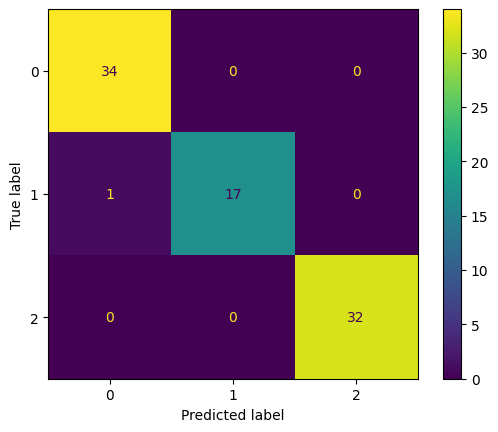

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, ovr_lgr.predict(X_test))
ConfusionMatrixDisplay(cm).plot();

In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, ovr_lgr.predict(X_test)))

              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.99        34
   Chinstrap       1.00      0.94      0.97        18
      Gentoo       1.00      1.00      1.00        32

    accuracy                           0.99        84
   macro avg       0.99      0.98      0.99        84
weighted avg       0.99      0.99      0.99        84



In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, ovr_pos_probs)
auc = roc_auc_score(y_test, ovr_pos_probs)

auc

ValueError: multiclass format is not supported

In [18]:
models = {
    'ovr': ovr_lgr,
    'multi': multi_lgr,
    'ovo': ovo_clf
}

results = []

for name, model in models.items():
    probs = model.predict_proba(X_test)
    pos_probs = probs[:, 1]
    auc = roc_auc_score(y_test, pos_probs)
    acc = accuracy_score(y_test, model.predict(X_test))
    results.append((name, acc, auc))

pd.DataFrame(results, columns=['model', 'accuracy', 'auc'])

ValueError: multi_class must be in ('ovo', 'ovr')

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ovr_regions(model, X, y, feature_names):
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid).reshape(xx.shape)

    plt.contourf(xx, yy, preds, alpha=0.4, cmap='Pastel2')
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolor='k')
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title('OVR Decision Regions')
    plt.show()

In [20]:
plot_ovr_regions(
    ovr_lgr,
    X[['feature1', 'feature2']],
    y,
    ['feature1', 'feature2']
)

KeyError: "None of [Index(['feature1', 'feature2'], dtype='object')] are in the [columns]"

In [21]:
x_vals = np.linspace(X.min().values[0], X.max().values[0], 500).reshape(-1, 1)
probs = ovr_lgr.predict_proba(x_vals)

plt.figure(figsize=(8, 5))
for i, cls in enumerate(ovr_lgr.classes_):
    plt.plot(x_vals, probs[:, i], label=f'Class {cls}')

plt.xlabel('balance')
plt.ylabel('Probability')
plt.title('OVR Probability Curves')
plt.legend()
plt.show()

/Users/garcia/Documents/Coding/code4AI-governance/Berkeley/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


ValueError: X has 1 features, but LogisticRegression is expecting 4 features as input.

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [28]:
features = ['flipper_length_mm', 'bill_length_mm']
X_2d = X[features]


In [29]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

ovr_2d = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, random_state=42)
)

ovr_2d.fit(X_2d, y)


,estimator,LogisticRegre...ndom_state=42)
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42


In [30]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ovr_regions(model, X, y, feature_names, step=1):
    # Encode class labels
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    x_min, x_max = X.iloc[:, 0].min() - 5, X.iloc[:, 0].max() + 5
    y_min, y_max = X.iloc[:, 1].min() - 5, X.iloc[:, 1].max() + 5

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, step),
        np.arange(y_min, y_max, step)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    # 🔑 Convert class predictions → numeric
    preds = model.predict(grid)
    preds_enc = le.transform(preds)
    preds_enc = preds_enc.reshape(xx.shape)

    plt.contourf(xx, yy, preds_enc, alpha=0.4, cmap='Pastel2')
    plt.scatter(
        X.iloc[:, 0],
        X.iloc[:, 1],
        c=y_enc,
        edgecolor='k',
        cmap='Set1'
    )

    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])


/Users/garcia/Documents/Coding/code4AI-governance/Berkeley/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/garcia/Documents/Coding/code4AI-governance/Berkeley/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/garcia/Documents/Coding/code4AI-governance/Berkeley/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


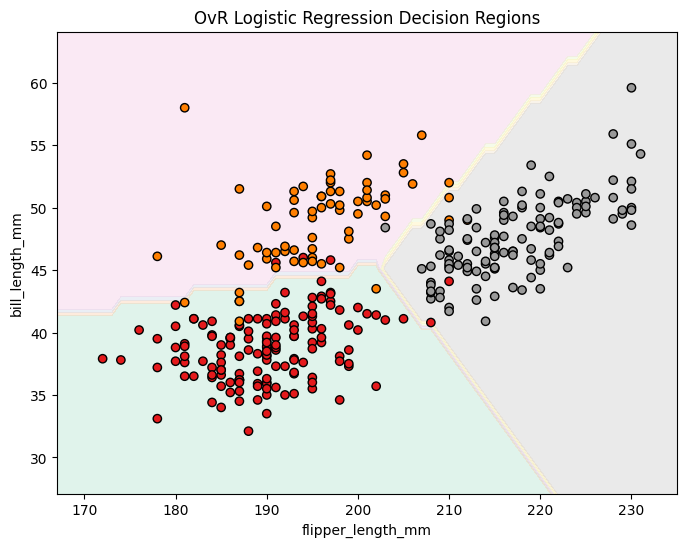

In [31]:
plt.figure(figsize=(8, 6))
plot_ovr_regions(
    ovr_2d,
    X_2d,
    y,
    feature_names=features
)
plt.title("OvR Logistic Regression Decision Regions")
plt.show()
